# 04 — Evaluation: final model (XGBoost MAE-log)

Metrik final di test set, lift vs baseline, dan plot diagnostik. Memuat artifact tersimpan
(`outputs/model_xgb.json`) — tanpa retrain.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, xgboost as xgb
from src.data import load_raw, add_gap_flag, clean_outliers, time_split, sequence_ready
from src import features as F, models as Mdl, metrics as M

clean, _ = clean_outliers(add_gap_flag(load_raw()), verbose=False)
feat = F.build_base_features(clean); tr, te = time_split(feat)
tr, te = F.add_dwell_feature(tr, te)              # D12 dwell terminal
art = F.fit_feature_artifacts(tr); tr = F.transform_with_artifacts(tr, art); te = F.transform_with_artifacts(te, art)  # D13 bus_encoded
te_c = sequence_ready(te)
model = xgb.XGBRegressor(); model.load_model("../outputs/model_xgb.json")
Xc, _, yc = Mdl.make_xy(te_c)
pred = Mdl.predict_sec(model, Xc)
base = F.predict_baseline(te_c, art["baseline_model"])

## Metrik final (common test set, dalam detik)

In [2]:
final = pd.DataFrame([Mdl.evaluate("Baseline (seg,hour mean)", yc, base, te_c),
                      Mdl.evaluate("XGBoost (final)", yc, pred, te_c)])
final["LoopMAE_lift_%"] = [0.0, round(100 * (final.LoopMAE_s[0] - final.LoopMAE_s[1]) / final.LoopMAE_s[0], 1)]
final

,Model,MAE_s,RMSE_s,MAPE_seg_%,LoopMAE_s,n_loops,LoopMAE_lift_%
0,"Baseline (seg,hour mean)",50.79,125.29,46.12,510.34,2325,0.0
1,XGBoost (final),31.81,93.95,23.63,258.83,2325,49.3


## Diagnostik: pred vs actual, distribusi error, MAE per jam

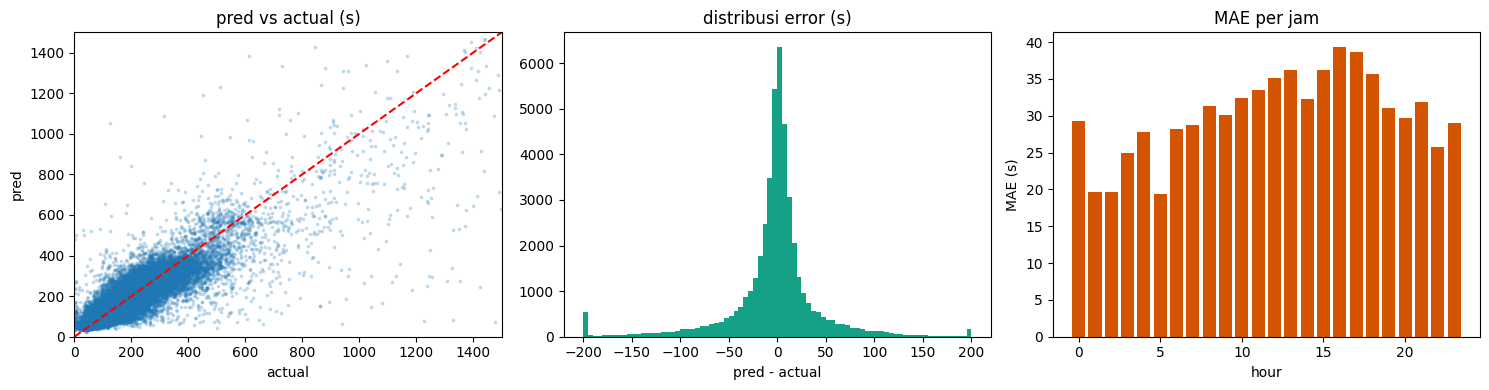

In [3]:
err = pred - yc
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].scatter(yc, pred, s=3, alpha=0.2); axs[0].plot([0, 1500], [0, 1500], "r--")
axs[0].set(title="pred vs actual (s)", xlim=(0, 1500), ylim=(0, 1500), xlabel="actual", ylabel="pred")
axs[1].hist(np.clip(err, -200, 200), bins=80, color="#16a085")
axs[1].set(title="distribusi error (s)", xlabel="pred - actual")
by_h = te_c.assign(ae=np.abs(err)).groupby("hour")["ae"].mean()
axs[2].bar(by_h.index, by_h.values, color="#d35400"); axs[2].set(title="MAE per jam", xlabel="hour", ylabel="MAE (s)")
plt.tight_layout(); plt.show()

## Loop MAE — akurasi satu putaran (metrik bisnis utama)

In [4]:
lm, n = M.loop_mae(te_c.assign(_p=pred), "traveling_time_sec", "_p")
lmb, _ = M.loop_mae(te_c.assign(_p=base), "traveling_time_sec", "_p")
print(f"Loop MAE  baseline {lmb:.1f}s  ->  XGBoost {lm:.1f}s   (lift {100*(lmb-lm)/lmb:.1f}%, {n} loop)")
print(f"Segment   MAE {M.mae(yc,pred):.1f}s | RMSE {M.rmse(yc,pred):.1f}s | "
      f"MAPE {M.mape_segment(yc,pred):.1f}% | sMAPE {M.smape(yc,pred):.1f}%")

Loop MAE  baseline 510.3s  ->  XGBoost 258.8s   (lift 49.3%, 2325 loop)
Segment   MAE 31.8s | RMSE 93.9s | MAPE 23.6% | sMAPE 20.3%
